# 14장 실습 — 모르면 무엇을 하는가

12·13장에서 신호를 만들었다. 알아채는 것과 **대처하는 것**은 다른 문제다.

선택지가 셋이다.

- **멈춘다** — 지금 하던 것을 중단한다. 가장 단순하고 가장 안전하다
- **물러선다** — 대본으로 쓴 제어기로 갈아탄다. 잘하지는 못해도 예측 가능하다
- **사람을 부른다** — 가장 비싸고 가장 확실하다

문헌의 수치가 이 선택의 값을 말해 준다. KnowNo 는 목표 수준 0.85 에서 **도움 없이 51%, 스텝의 67% 에서 도움을 요청해 76%** 를 냈다. ReconVLA 는 작업공간 경계 실험에서 기본 정책이 **20/20 보호 정지**를 당한 반면, 게이팅을 걸면 **4/20 보호 정지 + 16/20 사전 정지**였다고 보고한다.

마지막 대비가 이 장의 주제다. **걸려서 멈추는 것과 스스로 멈추는 것은 다르다.**

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (67s)


In [5]:
class Pert(Vec):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("평가 조건:", ", ".join(COND))

평가 조건: 명목, 배포


## 게이트와 세 가지 대응

12장에서 가장 좋았던 두 신호를 합쳐 게이트로 쓴다. 신호가 문턱을 넘으면 개입한다.

대응 셋을 코드로 적으면 이렇다.

- **멈춘다** — 명령을 0 으로 둔다. 로봇이 선다
- **물러선다** — 3권 6장의 서보 전문가로 갈아탄다. 학습된 정책이 아니라 손으로 쓴 비례 제어기다
- **사람을 부른다** — 개입 횟수만 세고, 사람이 오면 그 판은 해결된 것으로 친다

세 번째는 **상한**을 재는 것이다. 사람이 반드시 성공한다고 가정하므로 실제보다 낙관적이고, 대신 **개입률의 값**을 정직하게 보여 준다.

In [6]:
class AutoEnc(nn.Module):
    def __init__(self, d=8, h=16, z=4):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d, h), nn.Tanh(),
                                 nn.Linear(h, z))
        self.dec = nn.Sequential(nn.Linear(z, h), nn.Tanh(),
                                 nn.Linear(h, d))

    def forward(self, x):
        return self.dec(self.enc(x))


def collect_ok(policy, n=64, steps=400, seed=5):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    seen = [[] for _ in range(n)]
    keep = []
    for t in range(steps):
        o = env.obs()
        for i in range(n):
            seen[i].append(o[i])
        with torch.no_grad():
            a = policy.dist(torch.from_numpy(o)).sample().numpy()
        _, dn, sc = env.step(a)
        k = 0
        for i in range(n):
            if dn[i]:
                if sc[k] > .5:
                    keep += seen[i]
                seen[i] = []
                k += 1
    return torch.from_numpy(np.stack(keep))


def train_ae(X, epochs=200, seed=5):
    torch.manual_seed(seed)
    m = AutoEnc()
    opt = torch.optim.Adam(m.parameters(), 3e-3)
    mu, sd = X.mean(0, keepdim=True), X.std(0, keepdim=True) + 1e-6
    Z = (X - mu) / sd
    n = Z.shape[0]
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 1024):
            j = idx[k:k + 1024]
            loss = ((m(Z[j]) - Z[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return m, mu, sd


t0 = time.time()
AE, MU, SD = train_ae(collect_ok(POLICY))
print(f"자동부호기 학습 끝  ({time.time() - t0:.0f}s)")


def gate_signal(ot):
    """12장의 두 신호를 합친 위험도"""
    with torch.no_grad():
        v = POLICY.v(ot).squeeze(-1).numpy()
        z = (ot - MU) / SD
        rec = ((AE(z) - z) ** 2).mean(-1).numpy()
    return (-v) / 6. + rec

자동부호기 학습 끝  (10s)


In [7]:
def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """3권 6장의 서보 전문가 — 손으로 쓴 비례 제어기"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    g = env.g
    dv = unit(g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    near = np.linalg.norm(g - b, axis=1) < .012
    cmd[near] = 0.
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


FAR = .38          # 이 밖으로 나가면 작업공간 이탈로 친다


def run_gate(thr, mode, cond="배포", seed=999, n=150, reps=2):
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    fired = np.zeros(n, bool)
    ok, hard, inter, done = 0, 0, 0, 0
    for t in range(EP * reps):
        ot = torch.from_numpy(env.obs())
        risk = gate_signal(ot)
        hit = (risk > thr) & (~fired)
        inter += int(hit.sum())
        fired |= risk > thr
        with torch.no_grad():
            a = POLICY.dist(ot).sample().numpy()
        if mode == "멈춘다":
            a = np.where(fired[:, None], 0., a).astype(np.float32)
        elif mode == "물러선다":
            s = servo(env)
            a = np.where(fired[:, None], s, a).astype(np.float32)
        _, dn, sc = env.step(a)
        j = 0
        for i in range(n):
            if dn[i]:
                good = sc[j] > .5
                if mode == "사람을 부른다" and fired[i]:
                    good = True
                d = env.d[i]
                out = np.linalg.norm(d.qpos[0:2]) > FAR
                ok += int(good)
                hard += int(out and not good)
                done += 1
                fired[i] = False
                j += 1
    return dict(ok=ok / done, hard=hard / done,
                inter=inter / done, n=done)

## 문턱을 훑는다

문턱이 낮으면 자주 개입하고, 높으면 거의 개입하지 않는다. 양 끝이 기준선이다.

In [8]:
t0 = time.time()
THRS = [99., 1.2, .8, .55, .35, -99.]
RES = {}
for mode in ("멈춘다", "물러선다", "사람을 부른다"):
    for thr in THRS:
        RES[(mode, thr)] = run_gate(thr, mode)
    print(f"{mode} 끝  ({time.time() - t0:.0f}s)")

def lab(thr):
    names = {99.: "개입 없음", -99.: "항상 개입"}
    return names.get(thr, f"{thr:.2f}")


for mode in ("멈춘다", "물러선다", "사람을 부른다"):
    print()
    print(pad(f"[{mode}]", 14) + pad("개입률", 10, True)
          + pad("성공률", 9, True) + pad("작업공간 이탈", 15, True)
          + pad("95% 구간", 15, True))
    for thr in THRS:
        r = RES[(mode, thr)]
        lo, hi = wilson(r["ok"] * r["n"], r["n"])
        print(pad(lab(thr), 14) + pad(f"{r['inter']:.2f}", 10, True)
              + pad(f"{r['ok']:.2f}", 9, True)
              + pad(f"{r['hard']:.2f}", 15, True)
              + pad(f"[{lo:.2f}, {hi:.2f}]", 15, True))

멈춘다 끝  (27s)


물러선다 끝  (56s)


사람을 부른다 끝  (84s)

[멈춘다]          개입률   성공률  작업공간 이탈       95% 구간
개입 없음           0.01     0.73           0.00   [0.68, 0.78]
1.20                0.23     0.71           0.00   [0.66, 0.76]
0.80                0.27     0.70           0.00   [0.65, 0.75]
0.55                0.28     0.69           0.00   [0.64, 0.74]
0.35                0.30     0.69           0.00   [0.63, 0.74]
항상 개입           1.00     0.00           0.00   [0.00, 0.01]

[물러선다]        개입률   성공률  작업공간 이탈       95% 구간
개입 없음           0.01     0.73           0.00   [0.68, 0.78]
1.20                0.23     0.92           0.00   [0.88, 0.95]
0.80                0.27     0.94           0.00   [0.91, 0.96]
0.55                0.28     0.94           0.00   [0.91, 0.96]
0.35                0.29     0.96           0.00   [0.93, 0.98]
항상 개입           1.00     0.90           0.00   [0.86, 0.93]

[사람을 부른다]    개입률   성공률  작업공간 이탈       95% 구간
개입 없음           0.01     0.74           0.00   [0.69, 0.79]
1.20                0.23     0

## 세 대응을 나란히

같은 개입률에서 어느 대응이 무엇을 주는지 본다.

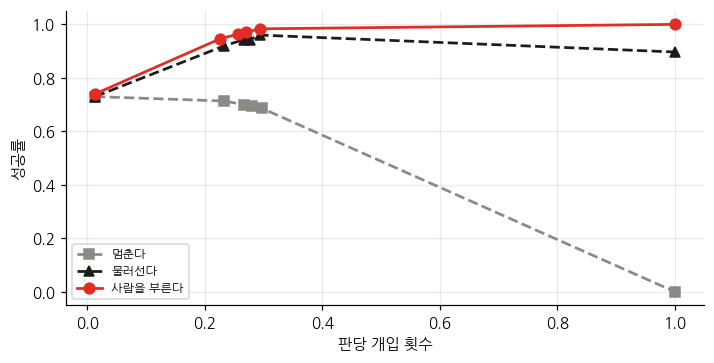

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 3.4))
for mode, col, mk in (("멈춘다", GREY, "s--"),
                      ("물러선다", INK, "^--"),
                      ("사람을 부른다", RED, "o-")):
    x = [RES[(mode, t)]["inter"] for t in THRS]
    y = [RES[(mode, t)]["ok"] for t in THRS]
    o = np.argsort(x)
    ax.plot(np.array(x)[o], np.array(y)[o], mk, color=col,
            lw=1.8, ms=7, label=mode)
ax.set_xlabel("판당 개입 횟수")
ax.set_ylabel("성공률")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

## 스스로 멈추는 것과 걸려서 멈추는 것

「작업공간 이탈」 열이 ReconVLA 가 잰 것에 대응한다. 블록이 목표에서 크게 벗어난 채 판이 끝난 경우이고, 실기라면 사람이 물건을 주우러 가야 하는 상황이다.

게이트가 작동하면 이 수가 줄어야 한다. **실패를 성공으로 바꾸지는 못해도, 나쁜 실패를 덜 나쁜 실패로 바꾸는 것**이 게이트의 최소한의 값이다.

In [10]:
print(pad("대응", 16) + pad("개입 없음", 14, True)
      + pad("문턱 0.55", 14, True) + pad("줄어든 폭", 12, True))
for mode in ("멈춘다", "물러선다"):
    a = RES[(mode, 99.)]["hard"]
    b = RES[(mode, .55)]["hard"]
    print(pad(mode, 16) + pad(f"{a:.3f}", 14, True)
          + pad(f"{b:.3f}", 14, True)
          + pad(f"{(b - a) * 100:+.1f}pt", 12, True))
print()
print("값은 작업공간 이탈로 끝난 판의 비율")

대응                 개입 없음     문턱 0.55   줄어든 폭
멈춘다                   0.000         0.000      +0.0pt
물러선다                 0.000         0.000      +0.0pt

값은 작업공간 이탈로 끝난 판의 비율


## 정리

**게이트의 값은 세 가지로 나뉜다.** 성공률을 올리는가, 나쁜 실패를 줄이는가, 사람의 손을 얼마나 부르는가. 셋을 한 표에 놓아야 결정이 보인다.

**멈추는 것은 성공을 만들지 않는다.** 당연하다 — 멈춘 판은 성공하지 않는다. 값은 **나쁜 실패를 줄이는 데** 있고, 그것이 실기에서는 비용 절감이다.

**물러서는 것은 다른 정책을 쓰는 것이다.** 대본 제어기가 학습 정책보다 나을 수도 있고 아닐 수도 있다. 이 과제에서 어느 쪽인지는 표가 말해 준다.

**사람을 부르는 것이 상한이다.** KnowNo 가 51% 를 76% 로 올린 것이 이 곡선 위의 한 점이고, 그 대가가 「스텝의 67% 에서 도움 요청」이었다. **개입률을 적지 않은 성공률 개선은 읽을 수 없는 수다.**

다음 장은 게이트보다 강한 장치를 다룬다. 정책이 무엇을 내든 **애초에 위험한 명령이 나가지 못하게** 막는 필터다.